In [1]:
from PIL import Image as PILImage
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['image.origin'] = 'lower'  # we want to show images, not matrices, so we set the origin to the lower-left
plt.style.use('dark_background')  # Optional configuration: if run, this will look nice on dark background notebooks

In [2]:
from astropy import units as u
from astropy.modeling.polynomial import Polynomial1D
from astropy.modeling.models import Gaussian1D, Linear1D
from astropy.modeling.fitting import LinearLSQFitter
from IPython.display import Image
# astroquery provides an interface to the NIST atomic line database
from astroquery.nist import Nist

In [ ]:
hg_filename = "hg_lamp_lab.bmp"


In [4]:
hg_image = np.array(PILImage.open(hg_filename))

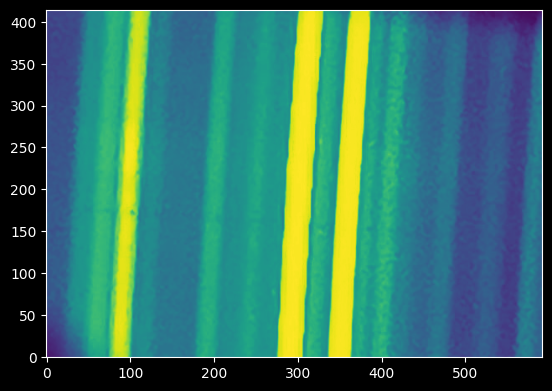

In [5]:
plt.imshow(hg_image);

In [6]:
trace_model = Polynomial1D(degree=3, c0=200, c1=-0.01596396, c2=0.0000008259, c3=3.3348554642250357e-09)
trace_profile_model = Gaussian1D(amplitude=200, mean=0.17719819, stddev=5.10872134)
xaxis = np.arange(hg_image.shape[1])
trace_center = trace_model(xaxis)
npixels_to_cut=15
yaxis = np.arange(-npixels_to_cut, npixels_to_cut)
model_trace_profile = trace_profile_model(yaxis)

In [17]:
linfitter = LinearLSQFitter()

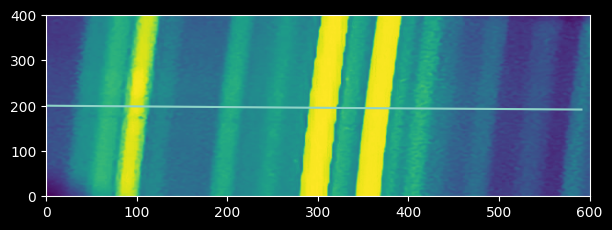

In [7]:
plt.figure(figsize=(16,8))
ax1 = plt.subplot(3,1,1)
ax1.imshow(hg_image[0:400,:], extent=[0,600,0,400])
ax1.plot(xaxis, trace_center)
ax1.set_aspect(0.5)

In [8]:
hg_spectrum = np.array([np.average(hg_image[int(yval)-npixels_to_cut:int(yval)+npixels_to_cut, ii],
                                weights=model_trace_profile)
                     for yval, ii in zip(trace_center, xaxis)])

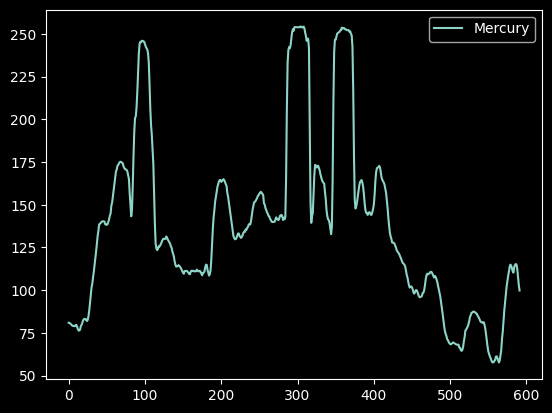

In [9]:
plt.plot(xaxis, hg_spectrum, label='Mercury')
plt.legend(loc='best');

# The optical lines of Mercury are, from Wikipedia, in Angstroms:

    - 4047 violet
    - 4358 blue
    - 5461 green
    - 5782 yellow-orange
    - 6500 red

In [10]:
guessed_wavelengths = [404.7, 435.8, 546.1, 578.2, 650.0]
guessed_xvals = [98, 200, 310, 350, 590]

In [11]:
npixels = 15
improved_xval_guesses = [np.average(xaxis[g-npixels:g+npixels],
                                    weights=hg_spectrum[g-npixels:g+npixels] - np.median(hg_spectrum))
                         for g in guessed_xvals]
improved_xval_guesses

[np.float64(97.761922442058),
 np.float64(203.2097312397874),
 np.float64(306.2503437594759),
 np.float64(354.608465694678),
 np.float64(583.25020087513)]

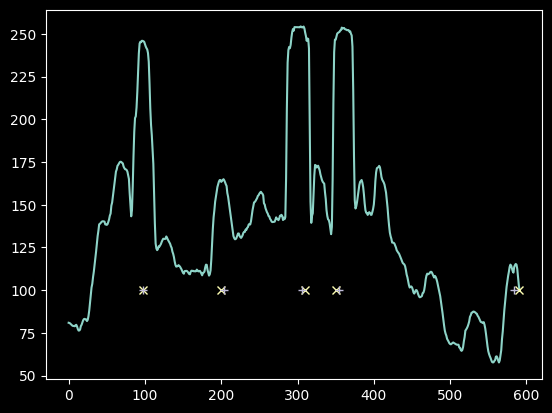

In [12]:
plt.plot(xaxis, hg_spectrum)
plt.plot(guessed_xvals, [100]*5, 'x')
plt.plot(improved_xval_guesses, [100]*5, '+');

In [13]:
linfitter = LinearLSQFitter()

In [14]:
wlmodel = Linear1D()
linfit_wlmodel = linfitter(model=wlmodel, x=improved_xval_guesses, y=guessed_wavelengths)
wavelengths = linfit_wlmodel(xaxis) * u.nm
linfit_wlmodel

<Linear1D(slope=0.53712037, intercept=356.98114063)>

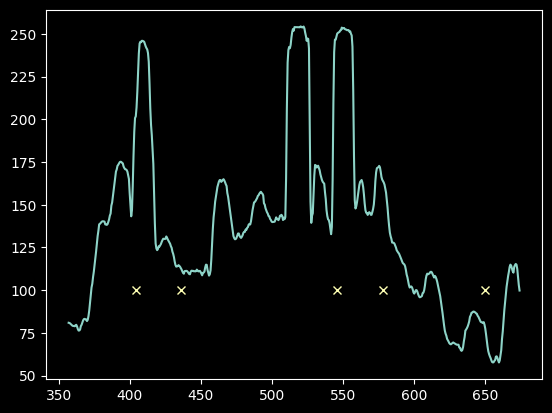

In [15]:
plt.plot(wavelengths, hg_spectrum)
plt.plot(guessed_wavelengths, [100]*5, 'x');

Text(0.5, 0, 'x (pixels)')

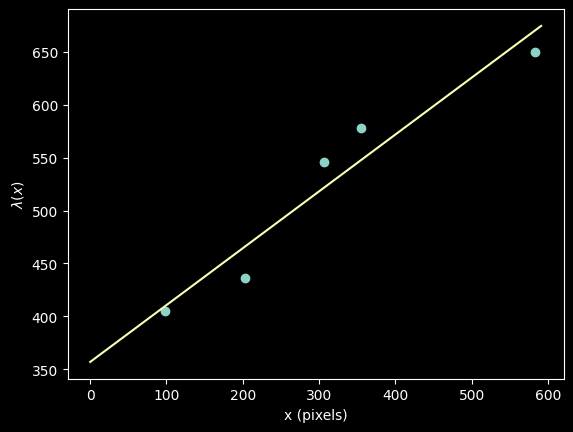

In [16]:
plt.plot(improved_xval_guesses, guessed_wavelengths, 'o')
plt.plot(xaxis, wavelengths, '-')
plt.ylabel("$\lambda(x)$")
plt.xlabel("x (pixels)")